# Minigrad

In the spirit of Andrej Karpathy's 'micrograd', we create a bite sized replication of the pytorch autograd system for error backpropegation in Neural networks. The difference between this minigrad version and Karpathy's micrograd is the implimentation of the Value class, Karpathy's implimentation uses exclusively scalar values to demonstrate the basic ideas behind backpropagation, wheras our minigrad implimentation shall utilise numpy arrays as the data element in the value class. Although the scope of the Neural net implimentation library in minigrad's case does not extend beyond that of micrograd (restricted soley to MLP architectures), the use of numpy arrays enables minigrad to efficiently handle batched gradient descent.

In [10]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Value Class

We first define our version of the value class. At first glance it appears almost identical to that of micrograd, however due to the use of numpy arrays we must handle teh gradient _backward() functions differently, namely for wrapped matrix multiplication operator '@'. It is this operators inclusion that shall allow for much faster forward and back propagation, along with trivial batched backpropagation.

In [27]:
class Value:
    def __init__(self, data = np.zeros(1), _children=(), op = ''):
        self.data = data
        self._children = set(_children)
        self.op = op
        self.grad = np.zeros_like(self.data, dtype=float)
        self._backward = lambda: None
        
    def __add__(self, value):
        data = self.data + value.data
        out = Value(data, (self, value), '+')
        def _backward():
            self.grad += out.grad
            value.grad += out.grad
        out._backward = _backward
        return out
        
    def __sub__(self, value):
        data = self.data - value.data
        out = Value(data, (self, value), '+')
        def _backward():
            self.grad += out.grad; value.grad += -out.grad
        out._backward = _backward
        return out
        
    def __matmul__(self, value):
        data = self.data @ value.data
        out = Value(data, (self,value), '@')
        def _backward():
            self.grad += out.grad @ value.data.T ; value.grad += self.data.T @ out.grad
        out._backward = _backward
        return out
        
    def __mul__(self, value):
        data = self.data * value.data
        out = Value(data, (self,value), '*')
        def _backward():
            self.grad += value.data * out.grad ; value.grad += self.data * out.grad
        out._backward = _backward
        return out
        
    def sigmoid(self):
        sig = 1 / (1 + np.exp(-self.data))
        out = Value(sig, (self,), 'sig')
        def _backward():
            self.grad += sig * (1 - sig) * out.grad
        out._backward = _backward
        return out
        
    def relu(self):
        out = Value(np.maximum(0, self.data), (self,), 'relu')
        def _backward():
            self.grad += (self.data > 0) * out.grad
        out._backward = _backward
        return out
        
    def tanh(self):
        t = np.tanh(self.data)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
        
    def leaky_relu(self, alpha=0.01):
        out = Value(np.where(self.data > 0, self.data, alpha * self.data), (self,), 'leaky_relu')
        def _backward():
            self.grad += np.where(self.data > 0, 1, alpha) * out.grad
        out._backward = _backward
        return out
        
    def backward(self):
        topo = []; visited = set()
        def build(node):
            if node not in visited:
                visited.add(node)
                for child in node._children: build(child)
                topo.append(node)
        build(self)
        self.grad = np.ones_like(self.data)
        for node in reversed(topo): node._backward()

## 2. MLP Architecture

Basic library for MLP object instantiation. The `MLP` class constructs a fully connected feedforward network of arbitrary depth and width, built entirely on top of the `Value` autograd engine.

**Layer initialisation** supports both He and Xavier schemes, selectable per instantiation.

**Supported activations:** `relu`, `tanh`, `sigmoid`, `leaky_relu` (hidden layers), `sigmoid`, `tanh` (output layer)

**Supported loss functions:** Half Squared Error (`HSE`)

**Training** (`fit`) handles train/validation splitting, mini-batch SGD with shuffling, and returns training and validation loss curves alongside final validation accuracy.

Example instantiation:
```python
model = MLP(input_dim=13, hidden=(8, 8), output_dim=1, 
            activation='relu', output_activation='sigmoid', 
            init='Xavier', loss='HSE')
```

In [59]:
def HSE(x, y):
    diff = x - y
    half = Value(np.full(diff.data.shape, 0.5))
    return diff * diff * half

class Layer:
    def __init__(self, dim, init = 'He'):
        self.bias = Value(np.zeros((1, dim[1])))
        if init == 'He':
            self.weights = Value((2/np.sqrt(dim[0]))*np.random.normal(size = dim))
        else: # Xavier Initialisation
            self.weights = Value((1/np.sqrt(dim[0]))*np.random.normal(size = dim))
            
    def zero_grad(self):
        self.bias.grad = np.zeros_like(self.bias.data)
        self.weights.grad = np.zeros_like(self.weights.data)

class MLP:
    def __init__(self, input_dim, hidden=(5, 5), output_dim=1, activation='relu', output_activation='sigmoid', init='He', loss = 'HSE'):
        # Create list of layers
        self.layers = []
        for index, i in enumerate(hidden):
            if index == 0:
                layer = Layer((input_dim, i), init)
            else:
                layer = Layer((hidden[index-1], i), init)
            self.layers.append(layer)
        self.layers.append(Layer((hidden[-1], output_dim), init))
        
        # Define activation functions
        if activation == 'relu':
            self.activation = Value.relu
        elif activation == 'tanh':
            self.activation = Value.tanh
        elif activation == 'sigmoid':
            self.activation = Value.sigmoid
        elif activation == 'leaky_relu':
            self.activation = Value.leaky_relu
        # Outut Activation Functions
        if output_activation == 'sigmoid':
            self.output_activation = Value.sigmoid
        elif output_activation == 'tanh':
            self.output_activation = Value.tanh

        # Define Loss function
        if loss == 'HSE':
            self.lossfunc = HSE

    def forward(self, data):
        x = Value(data)
        for _ in self.layers[:-1]:
            x = x @ _.weights + _.bias
            x = self.activation(x)
        x = x @ self.layers[-1].weights + self.layers[-1].bias
        x = self.output_activation(x)
        return x

    def fit(self, data, labels, validation_size, epochs, n_batch, alpha = 0.01):
        # Split data into training and validation set
        rng = np.random.default_rng()
        perm = rng.permutation(data.shape[0])
        X = data[perm]
        y = labels[perm]
        train_X = X[:-validation_size]
        train_y = y[:-validation_size]
        val_X = X[-validation_size:]
        val_y = y[-validation_size:]

        # Iterate over all epochs, impliments GD, tracks loss value agaisnt training data and validation set at close of epoch
        training = []
        validation = []
        for _ in range(epochs):
            # generate permutation for data set and split iterate through in batch_size steps
            perm = rng.permutation(train_X.shape[0])
            shuffled_X = train_X[perm]
            shuffled_y = train_y[perm]
            batches_X = np.array_split(shuffled_X, n_batch)
            batches_y = np.array_split(shuffled_y, n_batch)
            for batch_X, batch_y in zip(batches_X, batches_y):
                out = self.forward(batch_X)
                loss = self.lossfunc(out, Value(batch_y))
                # print(out.data.shape)
                # print(loss.data.shape)
                # print(batch_X.shape)
                # print(batch_y.shape)
                loss.backward()
                for layer in self.layers: # Update gradients based on batch
                    layer.bias.data -= alpha * (1/n_batch)* layer.bias.grad; layer.weights.data -= alpha*(1/n_batch)*layer.weights.grad
                    layer.zero_grad()

            # After iterating through all batches, update Training and validation curves
            out = self.forward(train_X)
            loss = self.lossfunc(out, Value(train_y))
            mean_loss = np.mean(loss.data)
            training.append(mean_loss)
            out = self.forward(val_X)
            loss = self.lossfunc(out, Value(val_y))
            mean_loss = np.mean(loss.data)
            validation.append(mean_loss)

        #Calculate Acuuracy on validation set
        out = self.forward(val_X)
        out_classified = (out.data > 0.5).astype(int)

        acc = np.sum(out_classified == val_y)/validation_size

        return training, validation, acc
            
                    
                
        

## 3. Testing

In [60]:
import pandas as pd

df = pd.read_csv('heart-disease.csv')
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values.reshape(-1, 1)

n_samples = X.shape[0]
print(n_samples)

rng = np.random.default_rng(seed=42)
indices = rng.permutation(n_samples)
X = X[indices]
y = y[indices]

# Normalise features to zero mean and unit variance
mu = X.mean(axis=0)
std = X.std(axis=0)
X = (X - mu) / std

303


In [61]:
model = MLP(13, (5, 5), 1, activation = 'sigmoid', init = 'x')

Accuracy =  0.8666666666666667


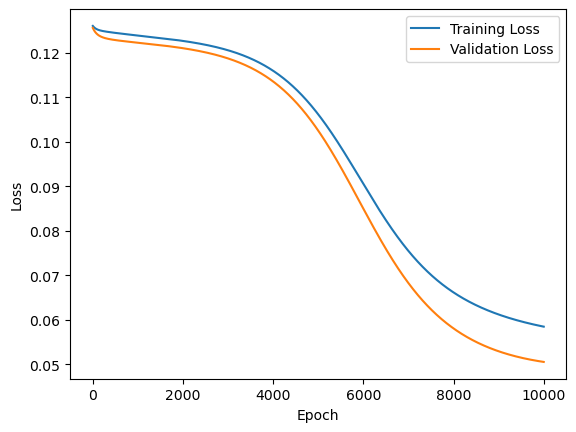

In [62]:
epochs = 10_000
n_batch = 50
alpha = 0.01

train, val, acc = model.fit(X, y, int(X.shape[0]/5), epochs, n_batch, alpha)
epoch_range = range(1, epochs + 1)

print("Accuracy = ", acc)

plt.plot(epoch_range, train, label='Training Loss')
plt.plot(epoch_range, val, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()